<a href="https://colab.research.google.com/github/adithya0x/Optimal-Portfolio-Allocation/blob/main/Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

In [2]:
print("1. Fetching and Preprocessing Data...")
TICKERS = ['AAPL', 'MSFT', 'JNJ', 'XOM', 'JPM']
TRADING_DAYS = 252

# Download historical data
df = yf.download(TICKERS, period="5y")

# Handle yfinance multi-index columns
try:
    prices = df.xs('Close', axis=1, level=0)
except KeyError:
    prices = df['Close']

# Clean missing values
prices = prices.ffill().dropna()

# Calculate simple daily returns and drop the first NaN row
daily_returns = prices.pct_change().dropna()

# Calculate annualized expected returns vector (mu) and covariance matrix (Sigma)
# Note: We extract .values to pass clean numpy arrays into CVXPY
mu = daily_returns.mean().values * TRADING_DAYS
Sigma = daily_returns.cov().values * TRADING_DAYS
n_assets = len(TICKERS)

print("Data preprocessing complete. Extracted expected returns and covariance matrix.\n")

1. Fetching and Preprocessing Data...


/tmp/ipykernel_16782/1381924542.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKERS, period="5y")
[*********************100%***********************]  5 of 5 completed

Data preprocessing complete. Extracted expected returns and covariance matrix.



In [3]:
print("2. Formulating and Solving the Global Minimum Variance (GMV) Portfolio...")

# Define CVXPY variable for weights
w = cp.Variable(n_assets)

# Define objective: Minimize portfolio variance (w^T * Sigma * w)
portfolio_variance = cp.quad_form(w, Sigma)
objective = cp.Minimize(portfolio_variance)

# Define constraints: Sum of weights = 1, Long-only (w >= 0)
constraints = [
    cp.sum(w) == 1,
    w >= 0
]

# Formulate and solve the problem
prob_gmv = cp.Problem(objective, constraints)
prob_gmv.solve()

# Extract GMV results
gmv_weights = w.value
gmv_return = mu @ gmv_weights
gmv_volatility = np.sqrt(gmv_weights.T @ Sigma @ gmv_weights)

print("Solver Status:", prob_gmv.status)
print("\nOptimal Weights (GMV Portfolio):")
for ticker, weight in zip(TICKERS, gmv_weights):
    print(f" - {ticker}: {weight:.4f} ({weight*100:.2f}%)")

2. Formulating and Solving the Global Minimum Variance (GMV) Portfolio...
Solver Status: optimal

Optimal Weights (GMV Portfolio):
 - AAPL: 0.0072 (0.72%)
 - MSFT: 0.5446 (54.46%)
 - JNJ: 0.0961 (9.61%)
 - XOM: 0.1907 (19.07%)
 - JPM: 0.1614 (16.14%)


In [4]:
print("\n3. Constructing the Efficient Frontier...")

# Create an array of target returns from the GMV return up to the max asset return
target_returns = np.linspace(gmv_return, np.max(mu), 50)

frontier_volatility = []
frontier_returns = []
frontier_weights = []

# Loop through target returns and solve the optimization for each
for target in target_returns:
    # Variable for this specific iteration
    w_ef = cp.Variable(n_assets)

    # Same objective: Minimize variance
    obj_ef = cp.Minimize(cp.quad_form(w_ef, Sigma))

    # Added constraint: Portfolio return must be >= target
    const_ef = [
        cp.sum(w_ef) == 1,
        w_ef >= 0,
        mu @ w_ef >= target
    ]

    prob_ef = cp.Problem(obj_ef, const_ef)

    try:
        prob_ef.solve()
        if prob_ef.status == 'optimal':
            # Store the minimized volatility and the target return
            frontier_volatility.append(np.sqrt(w_ef.value.T @ Sigma @ w_ef.value))
            frontier_returns.append(target)
            frontier_weights.append(w_ef.value)
    except Exception as e:
        pass # Skip if solver fails to converge for a specific extreme point

print(f"Successfully optimized {len(frontier_returns)} portfolios for the Efficient Frontier.\n")


3. Constructing the Efficient Frontier...
Successfully optimized 50 portfolios for the Efficient Frontier.



In [5]:
print("4. Calculating Naive (Equal Weight) Portfolio...")
w_naive = np.ones(n_assets) / n_assets
naive_return = mu @ w_naive
naive_volatility = np.sqrt(w_naive.T @ Sigma @ w_naive)

print("Naive Portfolio Expected Return:", round(naive_return, 4))
print("Naive Portfolio Volatility:", round(naive_volatility, 4))

4. Calculating Naive (Equal Weight) Portfolio...
Naive Portfolio Expected Return: 0.1749
Naive Portfolio Volatility: 0.1551


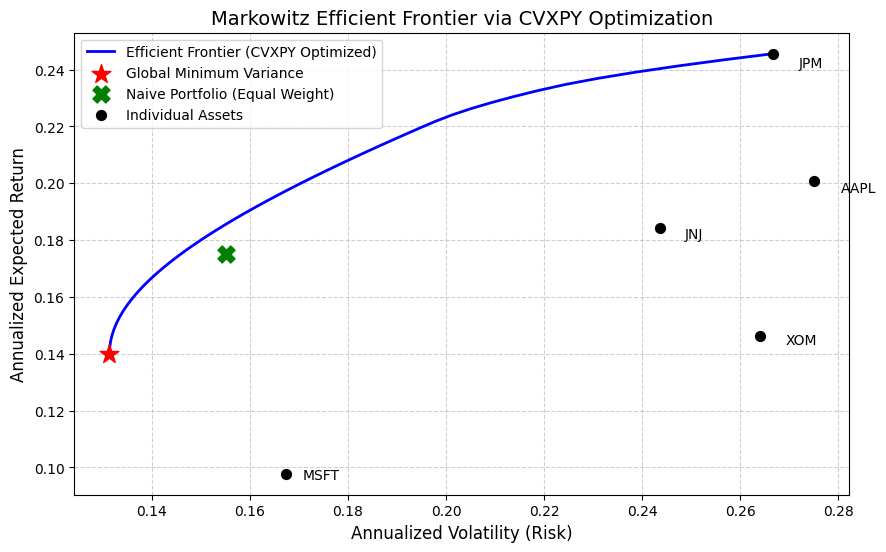

In [6]:
plt.figure(figsize=(10, 6))

# Plot Efficient Frontier
plt.plot(frontier_volatility, frontier_returns, 'b-', linewidth=2, label='Efficient Frontier (CVXPY Optimized)')

# Plot GMV Portfolio
plt.scatter(gmv_volatility, gmv_return, marker='*', color='red', s=200, label='Global Minimum Variance', zorder=5)

# Plot Naive Portfolio
plt.scatter(naive_volatility, naive_return, marker='X', color='green', s=150, label='Naive Portfolio (Equal Weight)', zorder=5)

# Plot Individual Assets
asset_vols = np.sqrt(np.diag(Sigma))
plt.scatter(asset_vols, mu, color='black', s=50, label='Individual Assets', zorder=4)

# Label Individual Assets
for i, ticker in enumerate(TICKERS):
    plt.annotate(ticker, (asset_vols[i] * 1.02, mu[i] * 0.98), fontsize=10)

# Chart Formatting
plt.title("Markowitz Efficient Frontier via CVXPY Optimization", fontsize=14)
plt.xlabel("Annualized Volatility (Risk)", fontsize=12)
plt.ylabel("Annualized Expected Return", fontsize=12)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()